In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

project name:seasonal agriculture performance

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.shape

(4000, 28)

In [ ]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [ ]:
df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].median()

,0
Rainfall_mm,582.00
Soil_Moisture_pct,26.40
Yield_Tonnes_Ha,1.74


In [ ]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(582.00)

In [ ]:
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(26.40)

In [ ]:
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(1.74)

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Season'].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [ ]:
categorical_columns = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [ ]:
# Calculate the IQR for Yield
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

# Calculate the upper outlier limit
upper_limit = Q3 + 1.5 * IQR

# Select potential outliers
outliers = df[df['Yield_Tonnes_Ha'] > upper_limit]

print("Upper limit:", upper_limit)
print("Number of potential outliers:", len(outliers))

# Display the 20 highest-yield records
outliers[['State', 'District', 'Crop', 'Season',
          'Farm_Area_Hectares', 'Yield_Tonnes_Ha',
          'Production_Tonnes', 'Profit_INR']].sort_values(
              'Yield_Tonnes_Ha', ascending=False
          ).head(20)

Upper limit: 5.5
Number of potential outliers: 302


,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
1715,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44,641.10,1608291
3423,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,1424.40,3330582
3525,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13,648.18,1471529
1464,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98,703.65,2216708
3523,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46,75.00,234320
2782,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32,522.35,1236801
644,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34,668.26,1984818
2847,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76,672.24,2041678
357,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,1249.21,3378879
1178,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79,534.58,1200815


In [ ]:
outliers['Crop'].value_counts()


,count
Crop,
Sugarcane,293
Maize,7
Rice,2


In [ ]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

crop_yield


,count,mean,median,min,max
Crop,,,,,
Sugarcane,305,46.642361,47.880,1.39,101.44
Maize,551,2.710036,2.840,0.30,6.08
Rice,690,2.431304,2.440,0.30,5.70
Wheat,614,2.108013,2.215,0.30,4.56
Chilli,412,1.542767,1.565,0.30,3.90
Groundnut,424,1.322901,1.400,0.30,3.02
Cotton,508,1.229783,1.255,0.30,2.90
Pulses,496,0.921512,0.945,0.30,2.09


In [ ]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

season_yield

,count,mean,median,min,max
Season,,,,,
Kharif,1779,5.628612,1.94,0.3,101.44
Rabi,1627,5.039435,1.67,0.3,93.13
Zaid,594,4.641313,1.46,0.3,64.76


In [ ]:
season_counts = df['Season'].value_counts()

season_counts

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


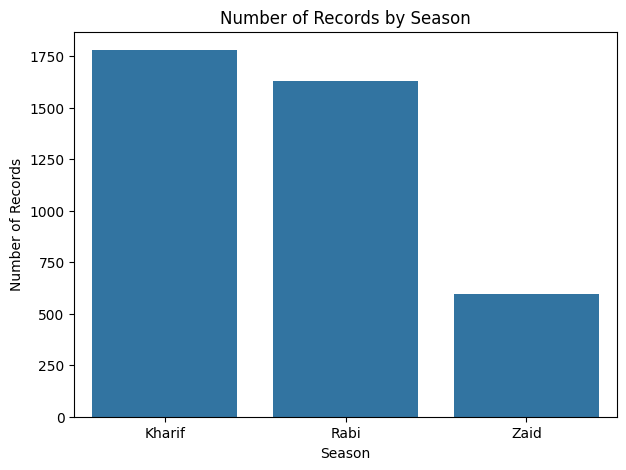

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Season')

plt.title('Number of Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.show()

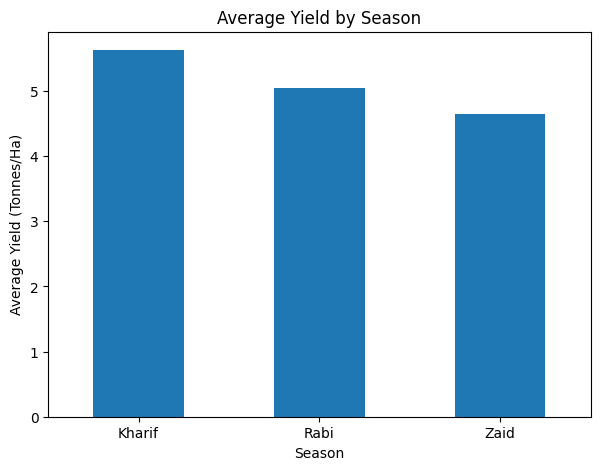

In [ ]:
season_yield_mean = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

plt.figure(figsize=(7, 5))

season_yield_mean.plot(kind='bar')

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)

plt.show()

In [ ]:
season_crop_yield = df.groupby(
    ['Season', 'Crop']
)['Yield_Tonnes_Ha'].mean().unstack()

season_crop_yield

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731459,1.374512,1.484974,2.966410,1.036063,2.698376,53.459120,2.253664
Rabi,1.465031,1.198358,1.233164,2.603648,0.875962,2.322847,43.286124,2.057468
Zaid,1.195312,0.960217,1.037778,2.290952,0.669677,1.900490,38.423922,1.748588


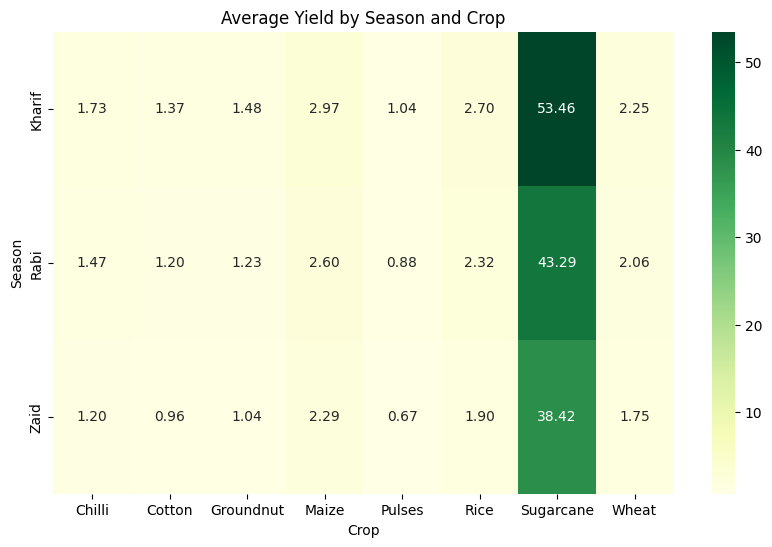

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGn'
)

plt.title('Average Yield by Season and Crop')
plt.xlabel('Crop')
plt.ylabel('Season')

plt.show()

In [ ]:
season_profit = df.groupby('Season')['Profit_INR'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

season_profit

,count,mean,median,min,max
Season,,,,,
Kharif,1779,178914.647555,38808.0,-976860,4345421
Rabi,1627,87689.470191,-3187.0,-1019223,3378879
Zaid,594,-24804.824916,-62144.0,-965197,2349990


In [ ]:
season_economics = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean().sort_values('Profit_INR', ascending=False)

season_economics

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.055649,531804.408094,178914.647555
Rabi,601526.048556,513836.578365,87689.470191
Zaid,519171.904040,543976.728956,-24804.824916


In [ ]:
season_economics['Profit_Margin_%'] = (
    season_economics['Profit_INR'] /
    season_economics['Revenue_INR']
) * 100

season_economics

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_%
Season,,,,
Kharif,710719.055649,531804.408094,178914.647555,25.173751
Rabi,601526.048556,513836.578365,87689.470191,14.577834
Zaid,519171.904040,543976.728956,-24804.824916,-4.777767


In [ ]:
season_economics.columns

Index(['Revenue_INR', 'Total_Cost_INR', 'Profit_INR', 'Profit_Margin_%'], dtype='object')

In [ ]:
season_economics

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_%
Season,,,,
Kharif,710719.055649,531804.408094,178914.647555,25.173751
Rabi,601526.048556,513836.578365,87689.470191,14.577834
Zaid,519171.904040,543976.728956,-24804.824916,-4.777767


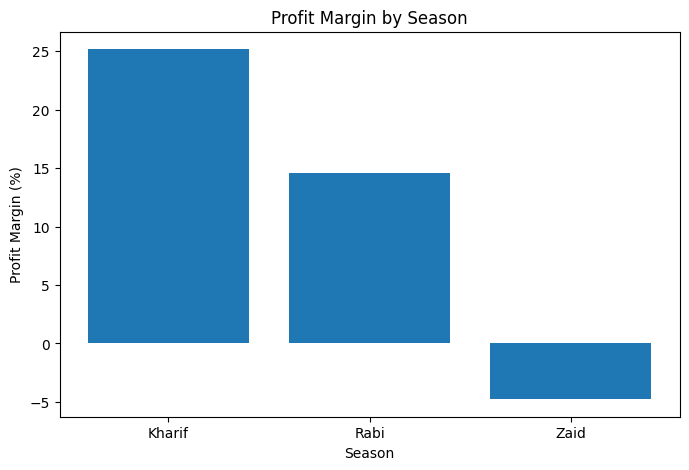

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_economics.index,
    season_economics['Profit_Margin_%']
)

plt.xlabel('Season')
plt.ylabel('Profit Margin (%)')
plt.title('Profit Margin by Season')

plt.show()

In [ ]:
season_economics

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_%
Season,,,,
Kharif,710719.055649,531804.408094,178914.647555,25.173751
Rabi,601526.048556,513836.578365,87689.470191,14.577834
Zaid,519171.904040,543976.728956,-24804.824916,-4.777767


In [ ]:
# Find the season with the highest profit
most_profitable_season = season_economics['Profit_INR'].idxmax()

most_profitable_profit = season_economics['Profit_INR'].max()

print("Most Profitable Season:", most_profitable_season)
print("Profit:", most_profitable_profit)

Most Profitable Season: Kharif
Profit: 178914.64755480608


In [ ]:
# Find the season with the highest profit margin
highest_margin_season = season_economics['Profit_Margin_%'].idxmax()

highest_margin = season_economics['Profit_Margin_%'].max()

print("Highest Profit Margin Season:", highest_margin_season)
print("Profit Margin:", highest_margin, "%")

Highest Profit Margin Season: Kharif
Profit Margin: 25.173751306184933 %


In [ ]:
crop_economics = df.groupby('Crop').agg({
    'Revenue_INR': 'sum',
    'Total_Cost_INR': 'sum',
    'Profit_INR': 'sum'
})

crop_economics

,Revenue_INR,Total_Cost_INR,Profit_INR
Crop,,,
Chilli,526032218,216670341,309361877
Cotton,324826926,261557093,63269833
Groundnut,230204651,211184808,19019843
Maize,251844463,298116521,-46272058
Pulses,262119070,264221144,-2102074
Rice,292294529,362821847,-70527318
Sugarcane,418453935,169211599,249242336
Wheat,245664400,321430979,-75766579


In [ ]:
crop_economics['Profit_Margin_%'] = (
    crop_economics['Profit_INR'] /
    crop_economics['Revenue_INR']
) * 100

crop_economics

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_%
Crop,,,,
Chilli,526032218,216670341,309361877,58.810443
Cotton,324826926,261557093,63269833,19.478014
Groundnut,230204651,211184808,19019843,8.262145
Maize,251844463,298116521,-46272058,-18.373268
Pulses,262119070,264221144,-2102074,-0.801954
Rice,292294529,362821847,-70527318,-24.128853
Sugarcane,418453935,169211599,249242336,59.562670
Wheat,245664400,321430979,-75766579,-30.841497


In [ ]:
most_profitable_crop = crop_economics['Profit_INR'].idxmax()

print("Most Profitable Crop:", most_profitable_crop)
print("Profit:", crop_economics['Profit_INR'].max())

Most Profitable Crop: Chilli
Profit: 309361877


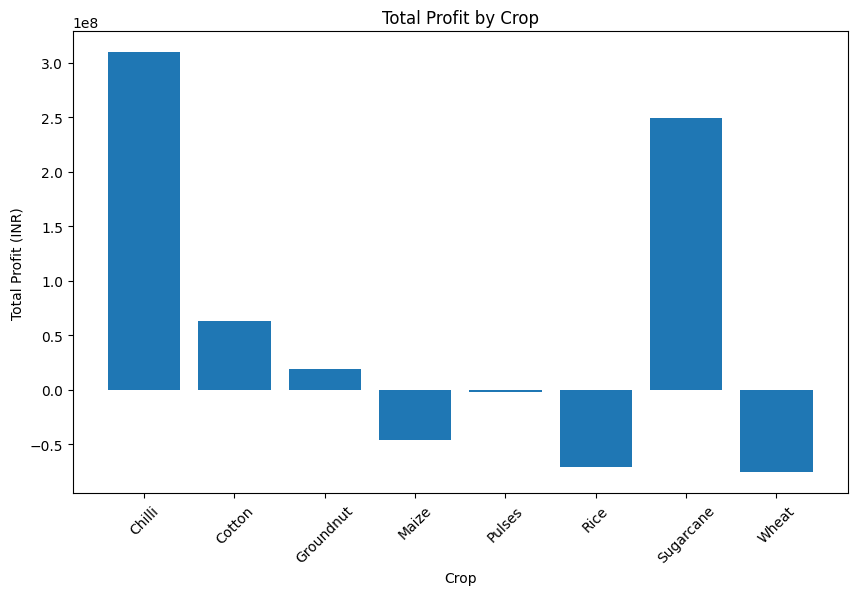

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    crop_economics.index,
    crop_economics['Profit_INR']
)

plt.xlabel('Crop')
plt.ylabel('Total Profit (INR)')
plt.title('Total Profit by Crop')
plt.xticks(rotation=45)

plt.show()

In [ ]:
highest_margin_crop = crop_economics['Profit_Margin_%'].idxmax()
highest_margin = crop_economics['Profit_Margin_%'].max()

print("Crop with Highest Profit Margin:", highest_margin_crop)
print("Profit Margin:", highest_margin, "%")

Crop with Highest Profit Margin: Sugarcane
Profit Margin: 59.562669902960764 %


In [ ]:
state_economics = df.groupby('State').agg({
    'Revenue_INR': 'sum',
    'Total_Cost_INR': 'sum',
    'Profit_INR': 'sum'
})

state_economics

,Revenue_INR,Total_Cost_INR,Profit_INR
State,,,
Andhra Pradesh,320925076,282068160,38856916
Gujarat,319490116,262116817,57373299
Karnataka,319525403,261127881,58397522
Madhya Pradesh,296986504,253826648,43159856
Maharashtra,332816727,263477153,69339574
Punjab,332133240,266296832,65836408
Tamil Nadu,305110307,248004104,57106203
Telangana,324452819,268296737,56156082


In [ ]:
state_economics['Profit_Margin_%'] = (
    state_economics['Profit_INR'] /
    state_economics['Revenue_INR']
) * 100

state_economics

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_%
State,,,,
Andhra Pradesh,320925076,282068160,38856916,12.107784
Gujarat,319490116,262116817,57373299,17.957770
Karnataka,319525403,261127881,58397522,18.276332
Madhya Pradesh,296986504,253826648,43159856,14.532598
Maharashtra,332816727,263477153,69339574,20.834161
Punjab,332133240,266296832,65836408,19.822288
Tamil Nadu,305110307,248004104,57106203,18.716576
Telangana,324452819,268296737,56156082,17.307935


In [ ]:
most_profitable_state = state_economics['Profit_INR'].idxmax()

print("Most Profitable State:", most_profitable_state)
print("Profit:", state_economics['Profit_INR'].max())

Most Profitable State: Maharashtra
Profit: 69339574


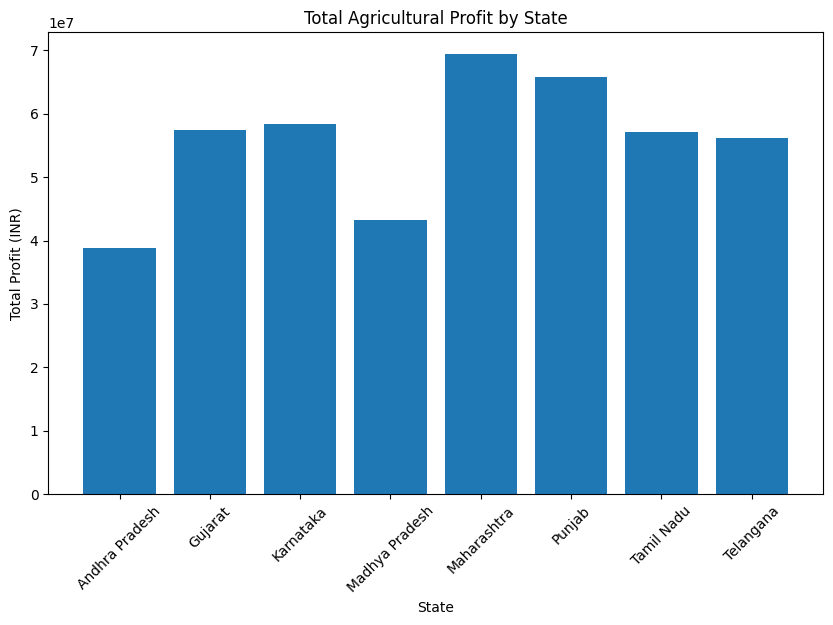

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    state_economics.index,
    state_economics['Profit_INR']
)

plt.xlabel('State')
plt.ylabel('Total Profit (INR)')
plt.title('Total Agricultural Profit by State')
plt.xticks(rotation=45)

plt.show()

In [ ]:
highest_margin_state = state_economics['Profit_Margin_%'].idxmax()
highest_margin = state_economics['Profit_Margin_%'].max()

print("State with Highest Profit Margin:", highest_margin_state)
print("Profit Margin:", highest_margin, "%")

State with Highest Profit Margin: Maharashtra
Profit Margin: 20.83416137915448 %


In [ ]:
# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation
correlation_matrix = numeric_df.corr()

correlation_matrix

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,...,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,...,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,...,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,...,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,...,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,...,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,...,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,...,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,...,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,...,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


In [ ]:
yield_correlation = correlation_matrix['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

yield_correlation

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [ ]:
profit_correlation = correlation_matrix['Profit_INR'].sort_values(
    ascending=False
)

profit_correlation

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281


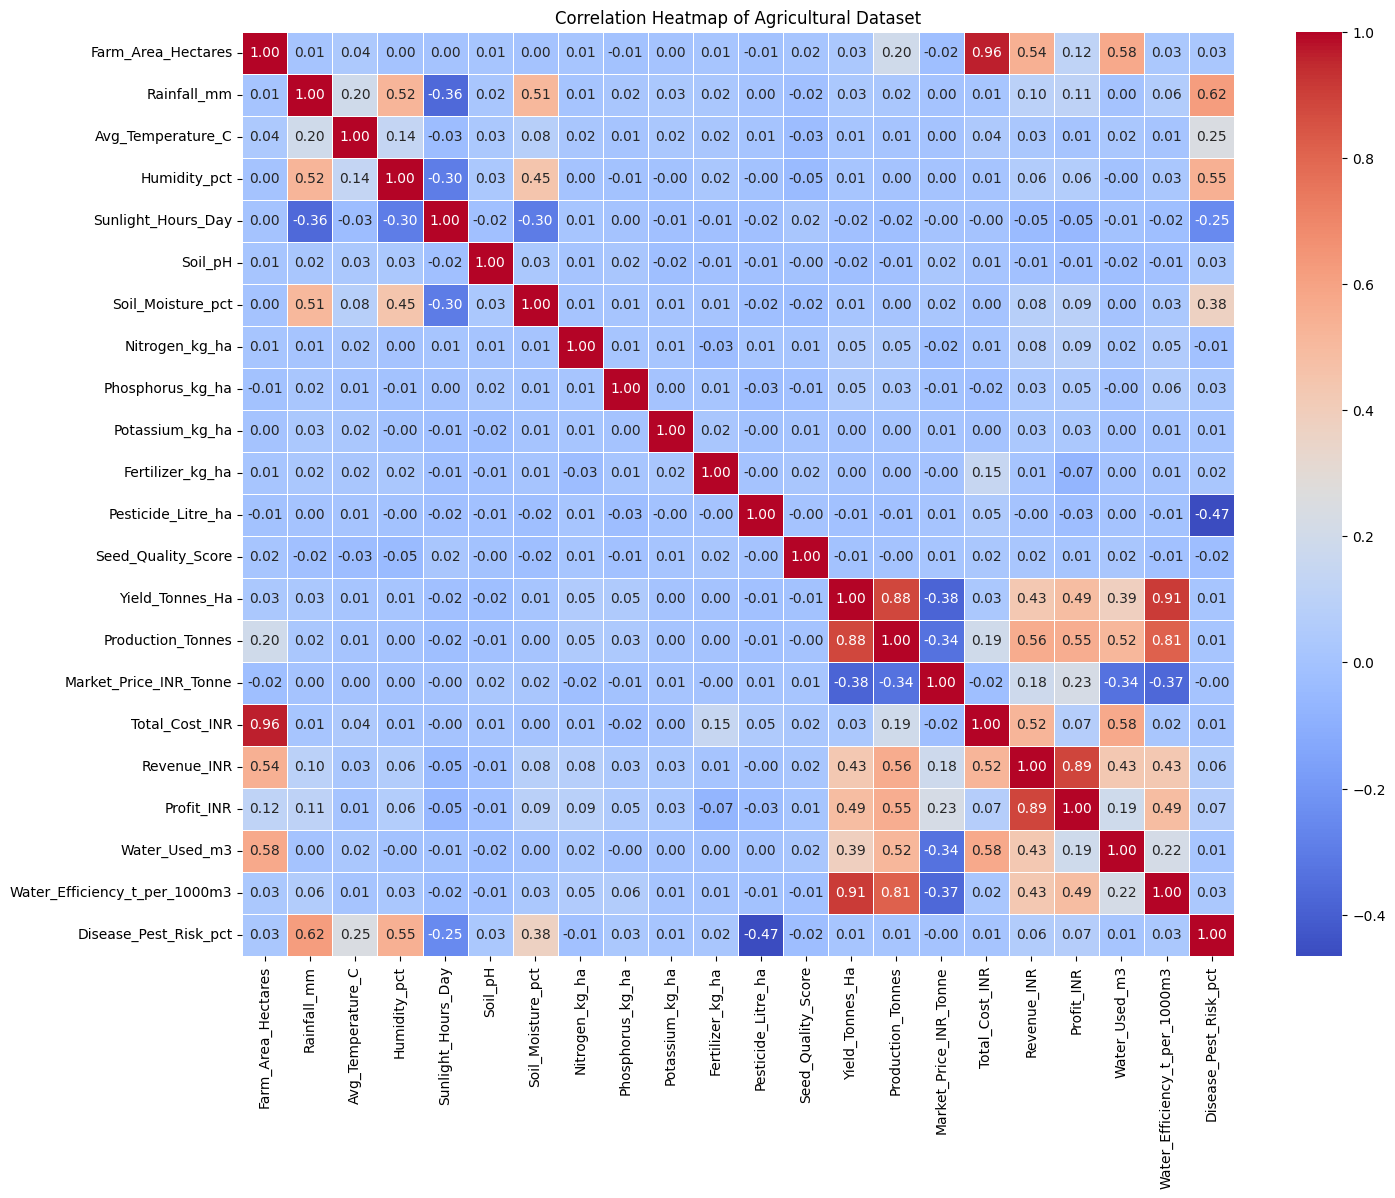

In [ ]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Agricultural Dataset")
plt.show()

In [ ]:
df.columns.tolist()


['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [ ]:
df[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR',
    'Total_Cost_INR', 'Profit_INR']].head()

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
0,2.46,1.30,30810,42662,-11852
1,0.30,1.96,40401,492351,-451950
2,0.52,2.53,190466,315210,-124744
3,1.84,8.28,200740,296444,-95704
4,2.21,9.30,193607,337959,-144352


In [ ]:
features = [
    'State',
    'Crop',
    'Season',
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Irrigation_Method',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct'
]

target = 'Yield_Tonnes_Ha'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4000, 19)
Target shape: (4000,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'State',
    'Crop',
    'Season',
    'Irrigation_Method'
]

numerical_features = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 4
Numerical features: 15


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3200
Testing samples: 800


In [ ]:
from sklearn.pipeline import Pipeline

preprocessing_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor)
    ]
)

X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (3200, 38)
Processed testing shape: (800, 38)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = model_rf.predict(X_test_processed)

print("First 10 predictions:")
print(y_pred_rf[:10])

First 10 predictions:
[2.00955 1.0089  1.6103  0.9271  1.38    1.0214  1.65435 0.5156  3.1916
 0.6375 ]


In [ ]:
season_conditions = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).round(2)

season_conditions

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha
Season,,,,
Kharif,849.20,28.45,31.15,5.63
Rabi,437.62,23.49,24.07,5.04
Zaid,304.65,31.04,19.28,4.64


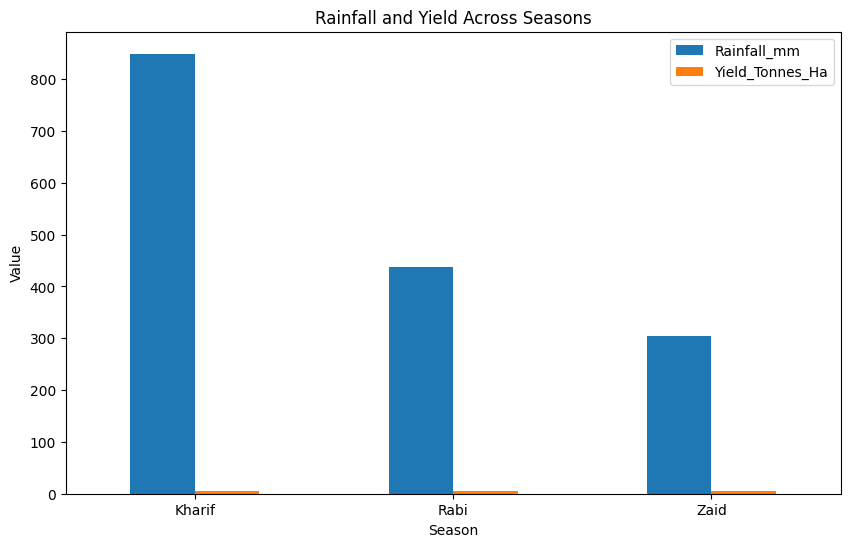

In [ ]:
season_conditions[['Rainfall_mm', 'Yield_Tonnes_Ha']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Rainfall and Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.show()

In [ ]:
season_summary = df.groupby('Season').agg({
    'Farm_Area_Hectares': 'mean',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,
Kharif,7.94,849.20,28.45,31.15,5.63,46.31,710719.06,531804.41,178914.65,6102.20,54.47
Rabi,7.75,437.62,23.49,24.07,5.04,41.49,601526.05,513836.58,87689.47,5846.99,40.48
Zaid,8.09,304.65,31.04,19.28,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,38.22


In [ ]:
season_summary.sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,
Kharif,7.94,849.20,28.45,31.15,5.63,46.31,710719.06,531804.41,178914.65,6102.20,54.47
Rabi,7.75,437.62,23.49,24.07,5.04,41.49,601526.05,513836.58,87689.47,5846.99,40.48
Zaid,8.09,304.65,31.04,19.28,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,38.22


In [ ]:
season_summary.sort_values(
    'Profit_INR',
    ascending=False
)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,
Kharif,7.94,849.20,28.45,31.15,5.63,46.31,710719.06,531804.41,178914.65,6102.20,54.47
Rabi,7.75,437.62,23.49,24.07,5.04,41.49,601526.05,513836.58,87689.47,5846.99,40.48
Zaid,8.09,304.65,31.04,19.28,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,38.22


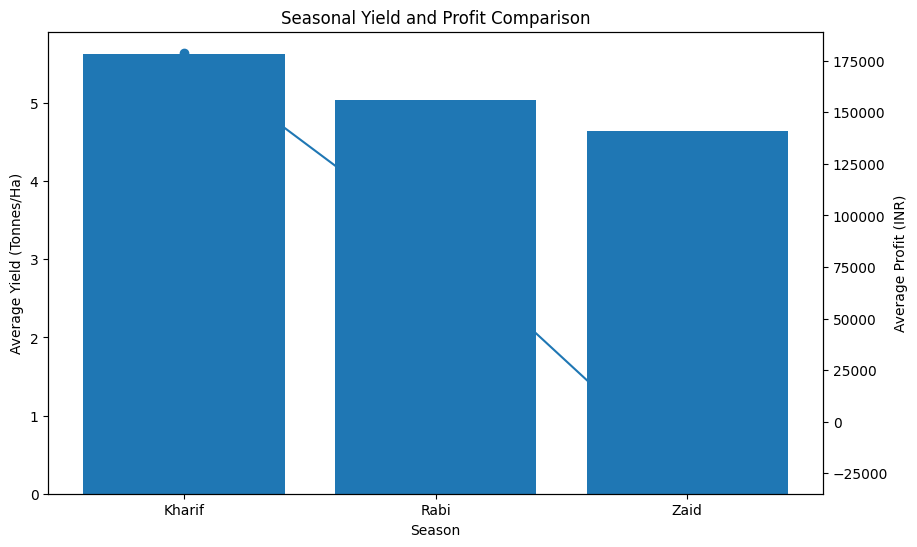

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    season_summary.index,
    season_summary['Yield_Tonnes_Ha']
)

ax1.set_xlabel('Season')
ax1.set_ylabel('Average Yield (Tonnes/Ha)')
ax1.set_title('Seasonal Yield and Profit Comparison')

ax2 = ax1.twinx()

ax2.plot(
    season_summary.index,
    season_summary['Profit_INR'],
    marker='o'
)

ax2.set_ylabel('Average Profit (INR)')

plt.show()

## Significant Observations

1. Kharif season shows the highest agricultural performance, with the highest average yield of 5.63 tonnes/ha and the highest average profit of ₹178,914.65.

2. Kharif receives the highest average rainfall (849.20 mm) and has the highest soil moisture (31.15%), which is associated with its higher yield compared with Rabi and Zaid.

3. Rabi shows moderate agricultural performance, with an average yield of 5.04 tonnes/ha and an average profit of ₹87,689.47.

4. Zaid records the lowest average rainfall (304.65 mm), lowest soil moisture (19.28%), and highest average temperature (31.04°C).

5. Zaid has the lowest average yield of 4.64 tonnes/ha and generates a negative average profit of ₹24,804.82, indicating poor economic performance.

6. An unusual pattern is observed in Zaid: it has the highest average water usage (6,419.89 m³), but still produces the lowest yield. This indicates lower water-use effectiveness during this season.

7. Kharif has the highest disease and pest risk (54.47%), indicating that its favorable growing conditions may also be associated with greater pest and disease pressure.

8. Overall, the results indicate that seasonal environmental conditions such as rainfall, temperature, and soil moisture are associated with differences in agricultural productivity and profitability.

## Data-Driven Recommendations

1. **Prioritize Kharif cultivation where suitable:** Kharif recorded the highest average yield (5.63 tonnes/ha), revenue (₹710,719.06), and profit (₹178,914.65). Farmers can consider prioritizing Kharif crops where environmental and farm conditions are suitable.

2. **Improve water management during Zaid:** Zaid used the highest average water (6,419.89 m³) but produced the lowest yield (4.64 tonnes/ha). Improving irrigation efficiency and adopting suitable water-management practices could help reduce water wastage.

3. **Select crops according to seasonal conditions:** The lower rainfall and soil moisture observed in Zaid suggest the importance of selecting crops that are better suited to relatively dry and hotter conditions.

4. **Strengthen pest and disease management in Kharif:** Kharif recorded the highest disease and pest risk (54.47%). Regular crop monitoring and timely preventive measures should therefore receive greater attention during this season.

5. **Improve Zaid-season profitability:** Zaid recorded an average loss of ₹24,804.82. Farmers should carefully evaluate input costs, expected yield, market prices, and water requirements before selecting crops for this season.

6. **Optimize resource allocation across seasons:** The differences in rainfall, temperature, soil moisture, yield, water use, and profitability indicate that farm inputs and irrigation strategies should be adjusted according to seasonal conditions rather than applying the same approach throughout the year.# New Section

## Conclusion

The analysis of the agricultural dataset shows clear variations in agricultural performance across the Kharif, Rabi, and Zaid seasons. Kharif emerged as the best-performing season, recording the highest average yield, revenue, and profit. Its higher rainfall and soil moisture levels were accompanied by better agricultural productivity.

Rabi demonstrated moderate performance, with lower rainfall and temperature than Kharif and positive profitability. In contrast, Zaid showed the weakest overall performance, with the lowest rainfall and soil moisture, the highest temperature, the lowest average yield, and a negative average profit.

An important observation was that Zaid recorded the highest average water usage but still produced the lowest yield. This indicates the need for improved water management and careful crop selection during the season. Kharif also showed the highest disease and pest risk, highlighting the importance of timely crop monitoring and pest-management practices.

Overall, the analysis demonstrates that seasonal environmental conditions and resource usage are associated with differences in agricultural productivity and economic performance. The findings can help farmers make more informed decisions about crop selection, irrigation, resource allocation, and seasonal farm management.# New Section